# Regression.

#### <p style="text-align: right;"> &#9989; **put your name here** </p>

### Regression = extracting physical laws from noisy data

Here, we will use 3 stress-strain datasets to practice regression.

- Download 3 stress-strain datasets.
    - `https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T000.csv`
    - `https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T400.csv`
    - `https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T600.csv`
- Load in data in `pandas`.
- Plot the data.

In [ ]:
# !Curl -O  https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T000.csv
# !Curl -O  https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T400.csv
# !Curl -O  https://raw.githubusercontent.com/huichiayu/cmse_202_802/main/data/stress_strain_T600.csv

In [1]:
import pandas as pd

data_000=pd.read_csv("stress_strain_T000.csv")
data_400=pd.read_csv("stress_strain_T400.csv")
data_600=pd.read_csv("stress_strain_T600.csv")
data_000.shape

(350, 2)

Text(0.5, 1.0, 'tensile test at different temperatures')

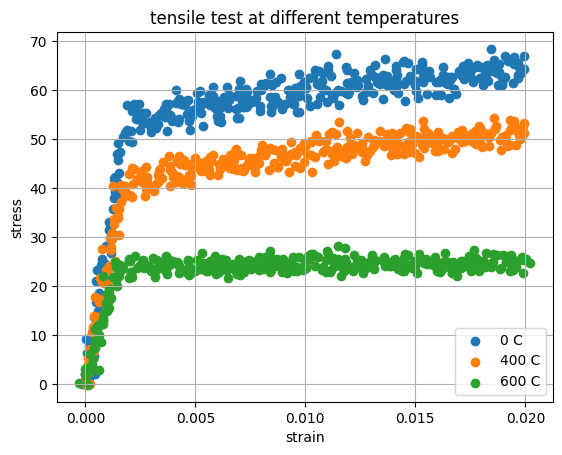

In [81]:
import matplotlib.pyplot as plt
plt.scatter(data_000["strain"],data_000["stress"],label='0 C')
plt.scatter(data_400["strain"],data_400["stress"],label='400 C')
plt.scatter(data_600["strain"],data_600["stress"],label='600 C')

plt.xlabel('strain')
plt.ylabel('stress')
plt.grid(True)
plt.legend()
plt.title("tensile test at different temperatures")

**These data are tensile test results of a metal at 3 different temperature.** 
We may see that the stress-strain curves have two regimes: linear elastic and plastic ones. 

### Elastic region

Our first task is to estimate the Young's modulus of this material. Let's select 0 degree C as an example. Below is a code that uses **machine learning** to fit the data. For now, let's skip the details of machine learning but study the code.

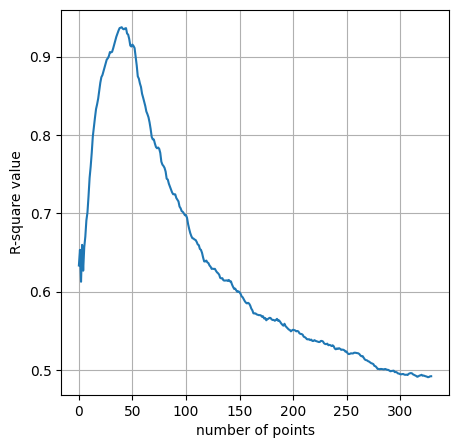

In [84]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

x = data_000["strain"].values
y = data_000["stress"].values

r2_list = []

min_points = 20

# loop over some data points
for i in range(min_points, len(x)):

    x_fit = x[:i].reshape(-1, 1)
    y_fit = y[:i]

    # fit the data using machine learning model.
    model_ml = LinearRegression()
    model_ml.fit(x_fit, y_fit)

    # use trained model to predict the values
    y_pred = model_ml.predict(x_fit)

    # calculate R2 value
    r2 = r2_score(y_fit, y_pred)
    r2_list.append(r2)


fig = plt.figure(figsize=(5,5))
plt.plot(r2_list)
plt.xlabel('number of points')
plt.ylabel('R-square value')
plt.grid(True)
plt.show()

The code above gradually increases the number of data points in a linear regression fit and calculates the R square values between the fitted values and the original data poitns.


In [9]:
threshold = 0.85

elastic_end = min_points

for i, r2 in enumerate(r2_list):
    if r2 < threshold:
        elastic_end = i + min_points
        break

print("Elastic region ends near:")
print("strain =", x[elastic_end])
print("stress =", y[elastic_end])
print("Young's modulus =", y[elastic_end]/x[elastic_end])

Elastic region ends near:
strain = 0.0006297625597915
stress = 18.67534559955778
Young's modulus = 29654.58220593609


&#9989; Do this: Explain how the code above works in finding the range of elastic region.

---
- Find the Young's moduli of the material at the 3 different temperature.
- Plot the Young's moduli versus temperatures.

Text(0, 0.5, "Young's modulus")

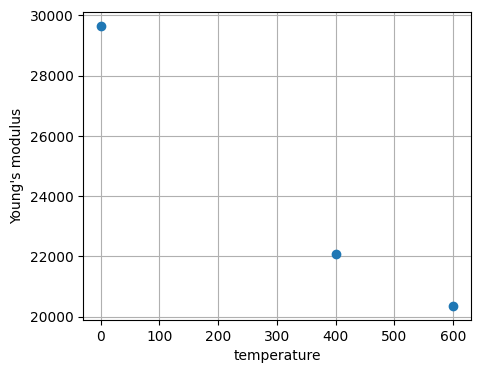

In [11]:
T = np.array([0, 400, 600])
E = np.array([29654.58220593609, 22092.283925416978, 20364.91232930956])

fig = plt.figure(figsize=(5,4))
plt.plot(T, E, 'o')
plt.grid(True)
plt.xlabel("temperature")
plt.ylabel("Young's modulus")

### Temperature effect

Here, we may see that the Young's modulus decreases as temperature increases, seemingly in an exponential form. Let's fit the temperature-Young's modulus data in an exponential expression:

$$y =a e^{-b x} + c.$$

- Predict the Young's modulus at 740 C using `curve_fit` method.

a = 11942.02077962021
b = 0.0025076949303921995
c = 17712.56142631588


/var/folders/qg/fd6rwmln2ys1_p2s6xdh0b800000gn/T/ipykernel_81529/2551437334.py:13: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(exp_model, T, E, p0=p0)


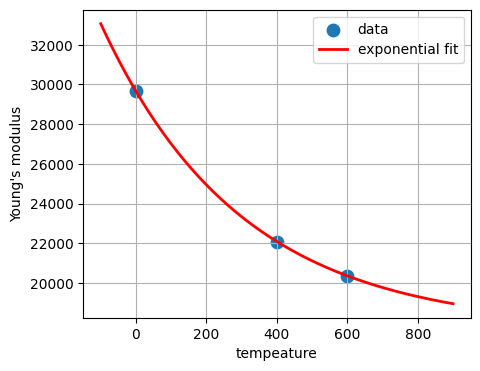

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# exponential model
def exp_model(x, a, b, c):
    return a*np.exp(-b*x) + c

# initial guess
p0 = [10000, 0.001, 20000]

# fit
popt, pcov = curve_fit(exp_model, T, E, p0=p0)

# fitted parameters
a_fit, b_fit, c_fit = popt

print("a =", a_fit)
print("b =", b_fit)
print("c =", c_fit)

# smooth fitted curve
x_fit = np.linspace(-100, 900, 200)
y_fit = exp_model(x_fit, *popt)

# plot
plt.figure(figsize=(5,4))

plt.scatter(T, E, s=80, label='data')
plt.plot(x_fit, y_fit, 'r', linewidth=2, label='exponential fit')

plt.xlabel("tempeature")
plt.ylabel("Young's modulus")
plt.grid(True)
plt.legend()

plt.show()

&#9989; Do this: 

- Intrapolate the value of Young's modulus at 200 C.
- Extrapolate the value of Young's modulus at 740 C.

In [91]:
E_200 = exp_model(200, *popt)
E_740 = exp_model(740, *popt)

print(f"{E_200} at 200 C")
print(f"{E_740} at 740 C")

24944.624554720904 at 200 C
19579.62905983752 at 740 C


---
### Full range of the stress-strain data

Assuming the stress-strain curve has a form of 

$$y = a \big( 1- e^{-k x}\big) + b x.$$

- Now, let's fit the whole data region using `least_squares` method.
- Build model and residual functions for this task. 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# -----------------------------
# model
# -----------------------------
def model_ss(params, x):
    A, k, B = params
    return A * (1 - np.exp(-k * x)) + B * x

# -----------------------------
# residuals
# -----------------------------
def residuals_ss(params, x, y):
    return model_ss(params, x) - y

- Test the `least_squares` model on the data at 0 C.

Fitted parameters: [ 56.36428179 808.60891664 383.577294  ]


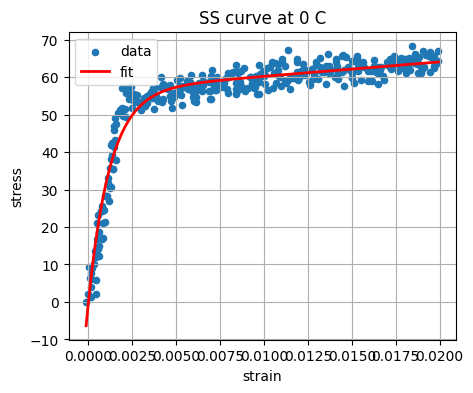

In [115]:
# extract data
x = data_000["strain"].values
y = data_000["stress"].values

# -----------------------------
# initial guess (IMPORTANT)
# -----------------------------
initial_guess = [60, 800, 200]  
# A ~ 60, k large (~fast rise), B small slope

# -----------------------------
# fit
# -----------------------------
result_ss = least_squares(residuals_ss, initial_guess, args=(x, y))

A_fit, k_fit, B_fit = result_ss.x
print("Fitted parameters:", result_ss.x)

# -----------------------------
# plot
# -----------------------------
x_fit = np.linspace(min(x), max(x), 200)
y_fit = model_ss(result_ss.x, x_fit)

plt.figure(figsize=(5,4))
plt.scatter(x, y, s=20, label="data")
plt.plot(x_fit, y_fit, 'r-', lw=2, label="fit")
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.legend()
plt.title("SS curve at 0 C")
plt.show()

**Fit the stress-strain curves at the 3 different temperatures and plot the predicted curves.**

In [23]:
# --------------------------------
# datasets
# --------------------------------
# list contains three datasets
strain_all = [data_000["strain"].values, data_400["strain"].values, data_600["strain"].values]
stress_all = [data_000["stress"].values, data_400["stress"].values, data_600["stress"].values]

temps = [0, 400, 600]


Temperature = 0
A = 56.36424262365112
k = 808.6111929750178
B = 383.5800058887138

Temperature = 400
A = 43.12444281460932
k = 917.3625029199961
B = 417.15469452894257

Temperature = 600
A = 24.755065540846694
k = 1149.0460324685678
B = -9.143047717924064


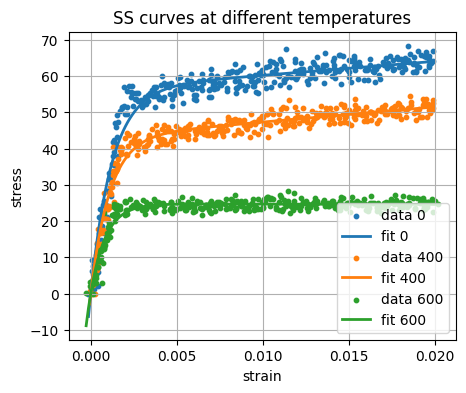

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# --------------------------------
# plotting
# --------------------------------
plt.figure(figsize=(5,4))

# --------------------------------
# loop over 3 datasets
# --------------------------------
for i in range(len(strain_all)):

    x = strain_all[i]
    y = stress_all[i]

    # initial guess
    p0 = [50, 1000, 100]

    # least-squares fit
    res_ss = least_squares(residuals_ss, p0, args=(x, y))

    # fitted parameters
    A_fit, k_fit, B_fit = res_ss.x

    print(f"\nTemperature = {temps[i]}")
    print("A =", A_fit)
    print("k =", k_fit)
    print("B =", B_fit)

    # smooth curve
    x_fit = np.linspace(np.min(x), np.max(x), 300)
    y_fit = model_ss(res_ss.x, x_fit)

    # plot data
    plt.scatter(x, y, s=10, label=f"data {temps[i]}")

    # plot fit
    plt.plot(x_fit, y_fit, linewidth=2, label=f"fit {temps[i]}")

# --------------------------------
# figure cosmetics
# --------------------------------
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.legend()
plt.title("SS curves at different temperatures")
plt.show()

---
### Global multi-variable constitutive fitting

Instead of fitting one curve at a time, we fit ALL temperatures simultaneously using strain and temperature as inputs.

### Idea

Currently our model is:

$$\sigma = A \big( 1-e^{-k \varepsilon} \big) + B \varepsilon.$$

Now let parameters depend on temperature:

$$A = A(T), ~~k = k(T), ~~\text{and}~~B = B(T)$$

For example:

$$A(T) = A_0 + A_1 T, $$

and same for $k(T)$ and $B(T)$. 
For this task, all strain and stress data will be used. So, let's combine all of the data points together. (use `np.concatenate`)

In [27]:
strain_total = np.concatenate([strain_all[0], strain_all[1], strain_all[2]])
stress_total = np.concatenate([stress_all[0], stress_all[1], stress_all[2]])

temp_total = np.concatenate([np.zeros(len(strain_all[0])),
    400*np.ones(len(strain_all[1])),
    600*np.ones(len(strain_all[2]))])

print(strain_total.shape, stress_total.shape, temp_total.shape)

(1050,) (1050,) (1050,)


In [29]:
def model_t(params, strain, temp):

    A0, A1, k0, k1, B0, B1 = params

    A = A0 + A1*temp
    k = k0 + k1*temp
    B = B0 + B1*temp

    return (A*(1 - np.exp(-k*strain))+ B*strain)

In [31]:
def residuals_total(params, strain, temp, stress):
    return (model_t(params, strain, temp)- stress)

In [33]:
from scipy.optimize import least_squares

p0 = [
    50,     # A0
    -0.05,  # A1

    1000,   # k0
    -1,     # k1

    100,    # B0
    -0.1    # B1
]

res_t = least_squares(residuals_total, p0,
    args=(strain_total, temp_total, stress_total))

In [35]:
print(res_t.x)

[ 5.99571144e+01 -5.52539557e-02  7.07656480e+02  8.95237423e-01
  3.14578040e+02 -1.73967411e-01]


- Predict the stress-strain curve at 900 C.

(200,) (200,)


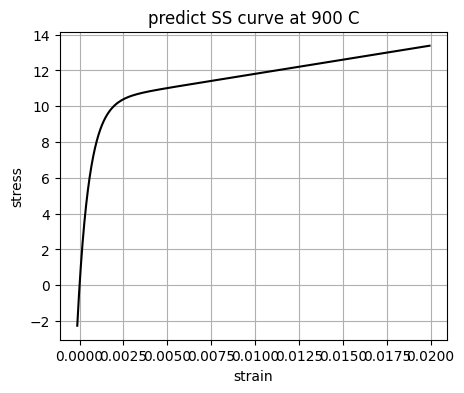

In [47]:
x_fit = np.linspace(np.min(x), np.max(x), 200)

Tmp = 900
y_pred_900 = model_t(res_t.x, x_fit, Tmp)
print(x_fit.shape, y_pred_900.shape)

plt.figure(figsize=(5,4))

plt.plot(x_fit, y_pred_900, 'k')
plt.xlabel("strain")
plt.ylabel("stress")
plt.grid(True)
plt.title("predict SS curve at 900 C")
plt.show()

**Plot all curves together.**

(200,) (200,)
(200,) (200,)
(200,) (200,)


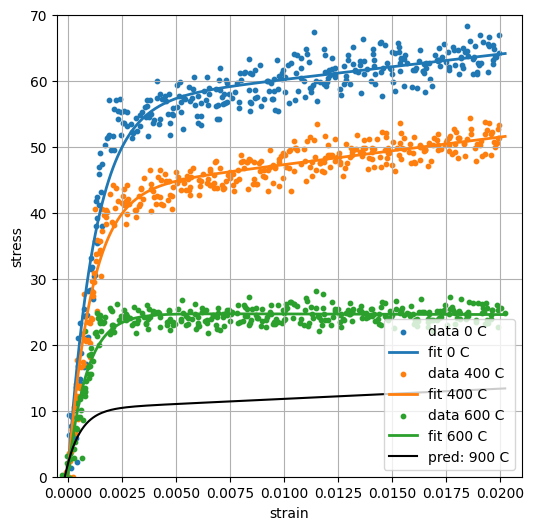

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

x_fit = np.linspace(np.min(x), np.max(x), 200)

# --------------------------------
# plotting
# --------------------------------
plt.figure(figsize=(6,6))

# --------------------------------
# loop over datasets
# --------------------------------
for i in range(len(strain_all)):

    x = strain_all[i]
    y = stress_all[i]

    # initial guess
    p0 = [50, 1000, 100]

    # least-squares fit
    res_ss = least_squares(residuals_ss, p0, args=(x, y))

    # fitted parameters
    A_fit, k_fit, B_fit = res_ss.x

    # smooth curve
    y_fit = model_ss(res_ss.x, x_fit)

    print(x_fit.shape, y_fit.shape)

    # plot data
    plt.scatter(x, y, s=10, label=f"data {temps[i]} C")

    # plot fit
    plt.plot(x_fit, y_fit, linewidth=2, label=f"fit {temps[i]} C")


# plot the prediction at 900 C
plt.plot(x_fit, y_pred_900, 'k' , label="pred: 900 C")


# --------------------------------
# figure cosmetics
# --------------------------------
plt.xlabel("strain")
plt.ylabel("stress")
plt.xlim([-0.0005,0.021])
plt.ylim([0, 70])
plt.grid(True)
plt.legend()
plt.show()

&#9989; Do this: Add one more predicted SS curve for temperature at 150 C.

In [124]:
Tmp = 150
y_pred_150 = model_t(res_t.x, x_fit, Tmp)

(200,) (200,)
(200,) (200,)
(200,) (200,)


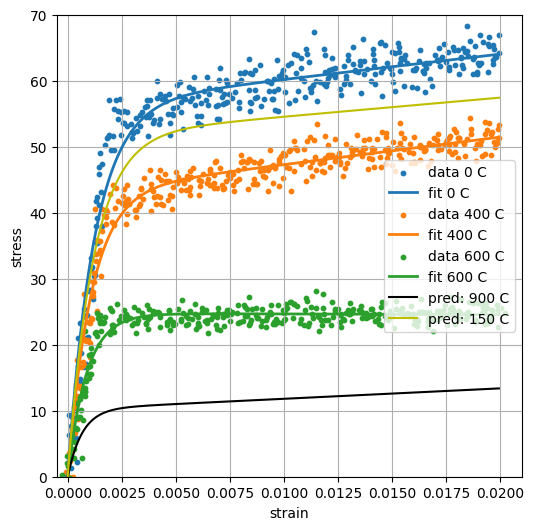

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

x_fit = np.linspace(np.min(x), np.max(x), 200)

# --------------------------------
# plotting
# --------------------------------
plt.figure(figsize=(6,6))

# --------------------------------
# loop over datasets
# --------------------------------
for i in range(len(strain_all)):

    x = strain_all[i]
    y = stress_all[i]

    # initial guess
    p0 = [50, 1000, 100]

    # least-squares fit
    res_ss = least_squares(residuals_ss, p0, args=(x, y))

    # fitted parameters
    A_fit, k_fit, B_fit = res_ss.x

    # smooth curve
    y_fit = model_ss(res_ss.x, x_fit)

    print(x_fit.shape, y_fit.shape)

    # plot data
    plt.scatter(x, y, s=10, label=f"data {temps[i]} C")

    # plot fit
    plt.plot(x_fit, y_fit, linewidth=2, label=f"fit {temps[i]} C")


# plot the prediction at 900 C
plt.plot(x_fit, y_pred_900, 'k' , label="pred: 900 C")

# plot the prediction at 150 C
plt.plot(x_fit, y_pred_150, 'y' , label="pred: 150 C")

# --------------------------------
# figure cosmetics
# --------------------------------
plt.xlabel("strain")
plt.ylabel("stress")
plt.xlim([-0.0005,0.021])
plt.ylim([0, 70])
plt.grid(True)
plt.legend()
plt.show()